In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
from pathlib import Path

# The standard device check — you'll use this pattern in every PyTorch notebook
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version:     {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")

Using device: cuda
PyTorch version:     2.10.0+cu128
TorchVision version: 0.25.0+cu128


## Tensor Question 1

In [127]:

# Create tensors
a = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])

b = torch.zeros(2, 3)
c = torch.ones(4)

# Function to print details
def tensor_info(name, t):
    print(f"{name}:")
    print("Value:\n", t)
    print("Shape:", t.shape)
    print("Dtype:", t.dtype)
    print("Device:", t.device)
    print("-" * 30)

# Print info
tensor_info("a", a)
tensor_info("b", b)
tensor_info("c", c)

a:
Value:
 tensor([[1., 2., 3.],
        [4., 5., 6.]])
Shape: torch.Size([2, 3])
Dtype: torch.float32
Device: cpu
------------------------------
b:
Value:
 tensor([[0., 0., 0.],
        [0., 0., 0.]])
Shape: torch.Size([2, 3])
Dtype: torch.float32
Device: cpu
------------------------------
c:
Value:
 tensor([1., 1., 1., 1.])
Shape: torch.Size([4])
Dtype: torch.float32
Device: cpu
------------------------------


## Tensor Question 2

In [128]:
# Given tensor
x = torch.tensor([1.0, 4.0, 9.0, 16.0, 25.0])

# Element-wise square root
sqrt_x = torch.sqrt(x)
print("Square root:", sqrt_x)

# Sum
sum_x = x.sum()
print("Sum:", sum_x)

# Mean
mean_x = x.mean()
print("Mean:", mean_x)

# Index of max value
argmax_x = x.argmax()
print("Argmax (index of max):", argmax_x)

Square root: tensor([1., 2., 3., 4., 5.])
Sum: tensor(55.)
Mean: tensor(11.)
Argmax (index of max): tensor(4)


## Tensor Question 3

In [129]:
# Original tensor
a = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move to GPU
a_gpu = a.to(device)
print(f"a_gpu device: {a_gpu.device}")

# Move back to CPU and convert to NumPy
a_back = a_gpu.cpu()
a_numpy = a_back.numpy()

print(f"numpy type: {type(a_numpy)}")
print(f"numpy values:\n{a_numpy}")

a_gpu device: cuda:0
numpy type: <class 'numpy.ndarray'>
numpy values:
[[1. 2. 3.]
 [4. 5. 6.]]


## Tensor Question 4

In [130]:
# Original tensor
t = torch.arange(24).float()

# 1. Reshape to (4, 6)
t1 = t.reshape(4, 6)
print("Shape (4,6):", t1.shape)

# 2. Reshape to (2, 3, 4)
t2 = t.reshape(2, 3, 4)
print("Shape (2,3,4):", t2.shape)

# 3. Add a new dimension at position 0
t3 = t1.unsqueeze(0)
print("After unsqueeze (add dim 0):", t3.shape)

Shape (4,6): torch.Size([4, 6])
Shape (2,3,4): torch.Size([2, 3, 4])
After unsqueeze (add dim 0): torch.Size([1, 4, 6])


## Tensor Question 5

In [131]:
# NumPy arrays
np_a = np.array([[1.0, 2.0], [3.0, 4.0]])
np_b = np.array([[5.0, 6.0], [7.0, 8.0]])

# PyTorch tensors
t_a = torch.tensor(np_a, dtype=torch.float32)
t_b = torch.tensor(np_b, dtype=torch.float32)

# 1. NumPy matrix multiplication
np_result = np.matmul(np_a, np_b)
print("NumPy result:\n", np_result)

# 2. PyTorch matrix multiplication
torch_result = torch.matmul(t_a, t_b)
print("PyTorch result:\n", torch_result)

# 3. Confirm outputs match
print("Do they match?", np.allclose(np_result, torch_result.numpy()))

NumPy result:
 [[19. 22.]
 [43. 50.]]
PyTorch result:
 tensor([[19., 22.],
        [43., 50.]])
Do they match? True


## Model Question 1

In [132]:
# Load pretrained ResNet18
weights = ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters:     11,689,512
Trainable parameters: 11,689,512


## Model Question 2

In [133]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Final layer name and output size:
The final layer is called fc (fully connected layer).
Its output size is 1000, which corresponds to the 1,000 ImageNet classes.
layer1 through layer4 (feature extractor):
Yes, these blocks (layer1, layer2, layer3, layer4) are the core feature extraction part of the network. Each layer is made of multiple convolutional blocks that progressively learn more complex patterns.
What “deep” means (in simple terms):
A network is called “deep” because it has many stacked layers.
As data passes through:
Early layers learn simple features (edges, colors)
Middle layers learn patterns (textures, shapes)
Deeper layers learn high-level concepts (objects, faces)

## Model Question 3

In [134]:
# Move model to the selected device (CPU or GPU)
model = model.to(device)

# Set model to evaluation mode
model.eval()

print("Model ready for inference.")

Model ready for inference.


Comment (Explanation)
.to(device)
This moves the model’s parameters (weights and buffers) to the specified device (e.g., CPU or GPU).
It must match your input tensors because PyTorch cannot perform operations on tensors located on different devices. If your model is on GPU but your input is on CPU (or vice versa), you’ll get a runtime error.

model.eval()
This switches the model to evaluation (inference) mode, changing how certain layers behave.

Example:

Dropout → turns OFF (no random neuron dropping)
BatchNorm → uses learned running statistics instead of batch statistics

## Model Question 4

In [135]:
preprocess = weights.transforms()
print(preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


Comment (Plain English Explanation)
Resize / Crop
This step resizes the image and then takes a center crop (typically to 224×224 for ResNet).
Why it matters:
The model expects a fixed input size
Keeps the subject centered and consistent with how the model was trained
Reduces distortion while standardizing inputs
ToTensor()
Converts the image from a PIL image (values 0–255) into a PyTorch tensor and scales pixel values to [0, 1].
Why it matters:
Neural networks work with tensors, not images
Scaling helps with numerical stability and training consistency
Normalization (using ImageNet mean & std)
This step shifts and scales each color channel using the same mean and standard deviation used during training on ImageNet.
Why it matters:
Makes the input distribution match what the model expects
Helps the model perform correctly because its learned weights depend on that exact data distribution
Using random values like mean=0.5, std=0.5 would mismatch the training conditions and hurt accuracy

## Running Inference

In [136]:
import random
random.seed(42)

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

def load_sample_image(label):
    """Load a random image file from the given class folder."""
    class_dir = DATA_DIR / label

    print(class_dir)
    img_path  = random.choice(list(class_dir.glob("*.jpg")))

    return Image.open(img_path).convert("RGB"), img_path.name


imagenet_classes = weights.meta["categories"]
print(f"Number of classes: {len(imagenet_classes)}")
print(f"First 5 labels: {imagenet_classes[:5]}")

Number of classes: 1000
First 5 labels: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']


## Inference Question 1

In [137]:


def get_top5_predictions(model, preprocess, image, device, class_labels):
    """
    Run inference on a PIL image and return the top-5 predictions.
    Returns a list of (class_name, probability) tuples.
    """

    # Step 1: Preprocess image + add batch dimension + move to device
    x = preprocess(image).unsqueeze(0).to(device)

    # Step 2: Run inference (no gradients needed)
    with torch.no_grad():
        logits = model(x)

    # Step 3: Convert logits to probabilities
    probs = F.softmax(logits[0], dim=0)

    # Step 4: Get top 5 predictions
    top_probs, top_indices = torch.topk(probs, 5)

    # Step 5: Map indices to class names
    results = [
        (class_labels[idx], top_probs[i].item())
        for i, idx in enumerate(top_indices)
    ]

    return results


In [139]:
import torch.nn.functional as F

img, img_name = load_sample_image("mountain")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

print(f"\nTop-5 predictions for '{img_name}':")
for class_name, prob in preds:
    print(f"  {class_name:30s}  {prob:.4f}")

/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/mountain

Top-5 predictions for '23578.jpg':
  alp                             0.6383
  valley                          0.1483
  mountain tent                   0.0711
  promontory                      0.0337
  geyser                          0.0216


Comment (Concept)

The top prediction usually does make sense in a semantic way, even if it doesn’t say “mountain” directly.

ImageNet does not have a single simple label like “mountain”
Instead, it includes more specific or related classes like:
alp
valley
cliff
lakeside
promontory

So often, the model’s top-5 predictions will describe parts or contexts of a mountain scene, rather than the general word “mountain” itself.

## Inference Question 2

In [140]:
for label in LABELS:
    img, img_name = load_sample_image(label)
    preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)[:3]
    print(f"\n[{label}]  {img_name}")
    for class_name, prob in preds:
        print(f"  {class_name:30s}  {prob:.4f}")

/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/buildings

[buildings]  22810.jpg
  palace                          0.2930
  monastery                       0.1951
  castle                          0.1165
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/forest

[forest]  23441.jpg
  stone wall                      0.0684
  worm fence                      0.0532
  barn                            0.0490
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/glacier

[glacier]  24115.jpg
  alp                             0.7151
  valley                          0.0614
  cliff                           0.0510
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/mountain

[mountain]  20974.jpg
  valley                          0.7217
  alp                             0.1105
  mountain tent                   0.0265
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_tes

## Inference Question 3

In [141]:
img, _ = load_sample_image("forest")
input_tensor = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)

probs = torch.nn.functional.softmax(logits[0], dim=0)

print(f"Logit  range: min={logits.min():.2f}, max={logits.max():.2f}")
print(f"Prob   range: min={probs.min():.6f}, max={probs.max():.4f}")
print(f"Probs sum to: {probs.sum():.6f}")
print(f"Top prediction: {imagenet_classes[probs.argmax().item()]}  ({probs.max():.4f})")

/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/forest
Logit  range: min=-4.84, max=7.08
Prob   range: min=0.000001, max=0.1689
Probs sum to: 1.000000
Top prediction: worm fence  (0.1689)


Comment (Concept)

Why logits instead of probabilities?
Neural networks output logits because they are:

Numerically stable → applying softmax too early can cause precision issues (especially with very large/small values)
Better for training → loss functions like cross-entropy combine logits + softmax internally in a more stable way
Unconstrained → the model can freely learn any real-valued scores without being restricted to [0, 1]

In short: logits make training more stable and efficient.

Which to use in production (logits vs probabilities)?
You usually work with probabilities, because:
They are interpretable (e.g., 0.92 = high confidence)
Easy to set thresholds like:
→ “only accept predictions if probability > 0.8”

## Inference Question 4

/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/forest


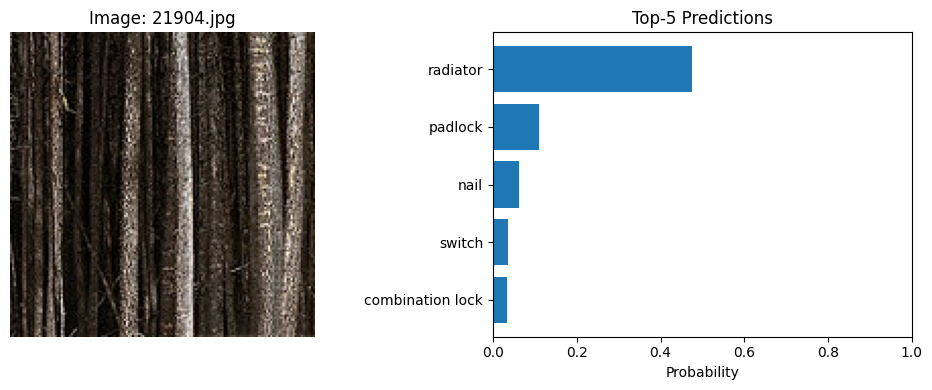

In [142]:
# Make sure output folder exists
os.makedirs("outputs", exist_ok=True)

# Get one sample + predictions
img, img_name = load_sample_image("forest")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

# Split labels and probs
labels = [p[0] for p in preds]
probs  = [p[1] for p in preds]

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Left: Image ---
axes[0].imshow(img)
axes[0].set_title(f"Image: {img_name}")
axes[0].axis("off")

# --- Right: Bar chart ---
axes[1].barh(labels[::-1], probs[::-1])  # reverse for top at top
axes[1].set_xlim(0, 1)
axes[1].set_title("Top-5 Predictions")
axes[1].set_xlabel("Probability")

plt.tight_layout()

# Save figure
plt.savefig("outputs/warmup_inference_viz.png")
plt.show()